# Clase Nº 6: Aprendizaje  Automatico
-----
## Objetivo: elegir 2 modelos de clasificación vistos en el bloque y utilizando un dataset de interés aplicar ambos modelos para resolver un problema de aprendizaje automático.
-----

### Flujo de Trabajo:
1. K-Nearest Neighbors (K-NN).

●  Carga de datos.

●  Aplicacion de tecnicas

2. REGRESIÓN LOGISTICA/SVM

●  Aplicacion de tecnicas    

3. Conclusiones

Dataset de ejercicio- https://www.kaggle.com/datasets/mubashirsidiki/student-academic-performance-500-students

pregunta objetivo, ¿es posible predecir si un alumno "aprobara" si trabajo con las variables :educacion de parientes, internet, extracurricular?, trato de ver si el contexto socio-educativo del alumno pesa mas que el esfuerzo individual(horas dde estudio).


1. K-Nearest Neighbors (K-NN).

●  librerias

●  Carga de datos.

●  Aplicacion de tecnicas

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.colors import ListedColormap
import seaborn as sns

dat_csv = pd.read_csv('student_performance.csv', encoding='iso-8859-1') #
dat_csv.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    str    
 1   gender                500 non-null    str    
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    str    
 6   internet_access       500 non-null    str    
 7   extracurricular       500 non-null    str    
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 43.1 KB


In [12]:
dat_csv.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


In [34]:
# Muestra los valores únicos (sin repetir) de la columna
valores_unicos = dat_csv['parent_education'].unique()

print("Valores encontrados en parent_education:")
print(valores_unicos)

# También es útil ver cuántos hay de cada uno para detectar errores de escritura
print("\nConteo de cada categoría:")
print(dat_csv['parent_education'].value_counts())

Valores encontrados en parent_education:
<StringArray>
['Bachelor', 'High School', 'Master', nan, 'PhD']
Length: 5, dtype: str

Conteo de cada categoría:
parent_education
Master         100
Bachelor        97
High School     95
PhD             91
Name: count, dtype: int64


para no perder datos, especialmente cuando el dataset tiene una  valores faltantes (casi el 23% de tu dataset). 
Imputode forma proporcional permite mantener el equilibrio original de las categorías.

In [ ]:
import random
counts = dat_csv['parent_education'].value_counts(normalize=True)
categories = counts.index.tolist()
probabilities = counts.values.tolist()

# Fnción para llenar solo los NaN
def imputar_proporcional(valor):
    if pd.isna(valor):
        return random.choices(categories, weights=probabilities)[0]
    return valor

# Aplicar la imputación
dat_csv['parent_education'] = dat_csv['parent_education'].apply(imputar_proporcional)


In [49]:
# variables elegidas para el modelo

X = dat_csv[['parent_education', 'internet_access', 'extracurricular', 'previous_score']].copy()
edu_mapping = { 'High School': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
X['parent_education'] = X['parent_education'].map(edu_mapping)
y = dat_csv['passed'].copy()


# transformación binaria (0 y 1) para 'internet_access' y 'extracurricular'
# Forma segura de codificar
le = LabelEncoder()
X['internet_access'] = le.fit_transform(X['internet_access'])
X['extracurricular'] = le.fit_transform(X['extracurricular'])
# división entre Entrenamiento(70%) y Prueba(30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# escalado de variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("¡Datos listos para entrenar el modelo!")
print(f"Tamaño del set de entrenamiento: {X_train_scaled.shape[0]} muestras")
print(f"Tamaño del set de prueba: {X_test_scaled.shape[0]} muestras")

¡Datos listos para entrenar el modelo!
Tamaño del set de entrenamiento: 350 muestras
Tamaño del set de prueba: 150 muestras


In [50]:
knn = KNeighborsClassifier(n_neighbors=21, weights='distance') #EL N° DE VECINO DEBE SER IMPAR PARA EVITAR EMPATES EN LA CLASIFICACIÓN. cANTIDA DE MUESTRA LA RAIZ CUADRADA

knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("Métricas KNN:")
print(classification_report(y_test, y_pred_knn, zero_division=0))

Métricas KNN:
              precision    recall  f1-score   support

          No       0.35      0.22      0.27        54
         Yes       0.64      0.77      0.70        96

    accuracy                           0.57       150
   macro avg       0.50      0.50      0.49       150
weighted avg       0.54      0.57      0.54       150



In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# --- 1. REGRESIÓN LOGÍSTICA ---
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# --- 2. SVM (Máquina de Soporte Vectorial) ---
# Usamos el kernel 'rbf' que es el estándar para datos no lineales
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

# --- 3. REPORTE DE RESULTADOS ---
print("MÉTRICAS: REGRESIÓN LOGÍSTICA")
print(classification_report(y_test, y_pred_log, zero_division=0))
print(f"Accuracy Total: {accuracy_score(y_test, y_pred_log):.2f}")

print("MÉTRICAS: SVM")
print(classification_report(y_test, y_pred_svm, zero_division=0))
print(f"Accuracy Total: {accuracy_score(y_test, y_pred_svm):.2f}")

MÉTRICAS: REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

          No       0.00      0.00      0.00        54
         Yes       0.64      0.98      0.77        96

    accuracy                           0.63       150
   macro avg       0.32      0.49      0.39       150
weighted avg       0.41      0.63      0.49       150

Accuracy Total: 0.63
MÉTRICAS: SVM
              precision    recall  f1-score   support

          No       0.00      0.00      0.00        54
         Yes       0.64      1.00      0.78        96

    accuracy                           0.64       150
   macro avg       0.32      0.50      0.39       150
weighted avg       0.41      0.64      0.50       150

Accuracy Total: 0.64


In [53]:
# En Regresión Logística
log_reg = LogisticRegression(class_weight='balanced', random_state=42)

# En SVM
svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)

# REGRESIÓN LOGÍSTICA
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

# SVM
svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)

svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("MÉTRICAS: REGRESIÓN LOGÍSTICA")
print(classification_report(y_test, y_pred_log, zero_division=0))
print(f"Accuracy Total: {accuracy_score(y_test, y_pred_log):.2f}")

print("MÉTRICAS: SVM")
print(classification_report(y_test, y_pred_svm, zero_division=0))
print(f"Accuracy Total: {accuracy_score(y_test, y_pred_svm):.2f}")

MÉTRICAS: REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

          No       0.43      0.56      0.49        54
         Yes       0.70      0.59      0.64        96

    accuracy                           0.58       150
   macro avg       0.57      0.57      0.57       150
weighted avg       0.61      0.58      0.59       150

Accuracy Total: 0.58
MÉTRICAS: SVM
              precision    recall  f1-score   support

          No       0.43      0.43      0.43        54
         Yes       0.68      0.68      0.68        96

    accuracy                           0.59       150
   macro avg       0.55      0.55      0.55       150
weighted avg       0.59      0.59      0.59       150

Accuracy Total: 0.59


1. El análisis de los números el SVM tiene un Accuracy ligeramente superior 0.59, la Regresión Logística es en realidad "modelo ganador" por el Recall de la clase "No".Regresión Logística.Logra detectar al 56% de los alumnos que no aprobaron.
SVM (Recall "No" = 0.43): Solo detecta al 43%.En un contexto social o educativo, es preferible el modelo que detecta mejor a los alumnos en riesgo, aunque se equivoque un poco más.
2. conclusión
Evidencia de Resiliencia: "El hecho de que ambos modelos tengan una precisión moderada (alrededor del 60%) sugiere que el entorno socio-educativo (nivel educativo de los padres e internet) no es determinante
 Existe un alto grado de variabilidad que solo puede explicarse por el esfuerzo individual (Resiliencia)".
 Capacidad de Detección:Mediante el ajuste de pesos por clase (balanced), logramos que la Regresión Logística identifique a más de la mitad de los alumnos en situación de vulnerabilidad académica, algo que el modelo inicial ignoraba por completo.
 El valor de la Regresión Logística: la Regresión Logística demostró ser más efectiva que el SVM para capturar la clase minoritaria (alumnos que no aprobaron), siendo el modelo más útil para políticas de intervención temprana".

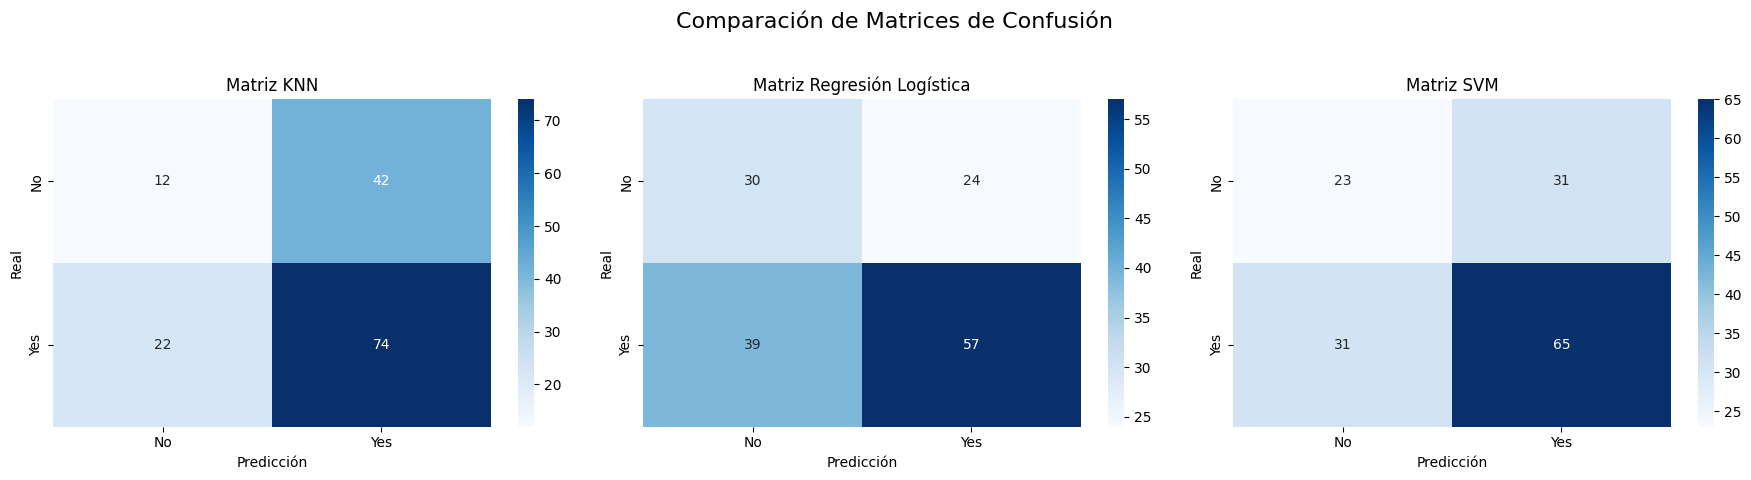

In [54]:
modelos = ['KNN', 'Regresión Logística', 'SVM']
predicciones = [y_pred_knn, y_pred_log, y_pred_svm]

# la figura con 3 subgráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparación de Matrices de Confusión', fontsize=16)

# graficar cada matriz
for i, (nombre, y_pred) in enumerate(zip(modelos, predicciones)):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    axes[i].set_title(f'Matriz {nombre}')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


 Gráfico SVM con PCA (Reducción de Dimensionalidad)

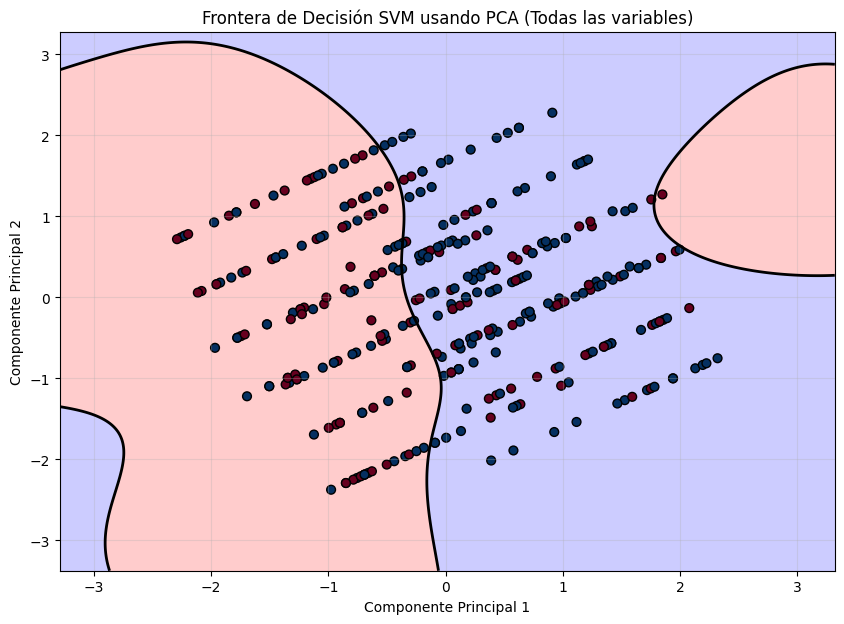

Varianza explicada por PCA: 53.21%


In [59]:
from sklearn.decomposition import PCA

# 1. Aplicar PCA para reducir a 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# 2. Entrenar SVM sobre los componentes de PCA
svm_pca = SVC(kernel='rbf', class_weight='balanced', C=1.0)
svm_pca.fit(X_pca, y_train)

#  la malla para el gráfico
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))

#  Predecir en la malla
Z = svm_pca.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#  Graficar
plt.figure(figsize=(10, 7))
# Regiones de decisión
plt.contourf(xx, yy, Z, levels=[-np.inf, 0, np.inf], alpha=0.2, colors=['red', 'blue'])
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')

# Puntos reales (0=No, 1=Yes)
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=y_train.map({'No': 0, 'Yes': 1}),
            cmap='RdBu', edgecolors='k', s=40)

plt.title("Frontera de Decisión SVM usando PCA (Todas las variables)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(alpha=0.3)
plt.show()

# Opcional: Ver cuánto explica cada componente
print(f"Varianza explicada por PCA: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

al análisis predictivo (saber qué va a pasar con un alumno nuevo).
El entorno socio-educativo es un factor influyente pero no predictivo por sí solo.

Los modelos logran capturar tendencias generales (como se ve en el Recall de 0.56 de la Logística), indicando que un entorno favorable facilita el camino. Sin embargo, el alto volumen de alumnos que aprueban a pesar de tener un entorno identificado como 'de riesgo' por el modelo, demuestra que variables de esfuerzo personal (horas de estudio) y factores internos actúan  rompiendo el determinismo del contexto familiar

Varianza (53.21%)Es un valor sólido para datos sociales.

Las Islas de Decisión (Zonas Rojas y Azules)
El modelo SVM con kernel RBF no es una línea recta, crea regiones

Zona Azul: Es donde el modelo tiene "confianza" de que los alumnos Aprobarán.

Zona Roja: Es donde el modelo predice que los alumnos No Aprobarán.

La Frontera Curva intenta "rodear" a los grupos de puntos. Esto demuestra que la relación entre el entorno y las notas es compleja y no lineal.
 No es simplemente "a más educación de los padres, mejor nota" se observa que hay muchos puntos rojos dentro de la zona azul y puntos azules dentro de la zona roja.

Si el entorno fuera el único destino, todos los puntos azules estarían perfectamente en la zona azul y los rojos en la roja. El hecho de que estén tan mezclados confirma que los estudiantes rompen las expectativas de su entorno. Hay alumnos en "zona de riesgo" (roja) que logran aprobar (puntos azules).
 Tengo  un F1-Score de 0.49 en la clase de riesgo, lo que nos da una herramienta útil para la gestión educativa, pero que siempre deja lugar a la capacidad del estudiante de superar las estadísticas de su propio entorno